## 0. Carga del conjunto de datos

El archivo `datos_8414.npz` contiene las señales personalizadas para esta evaluación. A partir de este archivo se cargan tres arreglos principales:

- $X$: matriz de señales, donde cada fila corresponde a una señal temporal.
- $y$: etiquetas de régimen de dispersión.
- $t$: vector temporal común a todas las señales.

En particular,

$$
X \in \mathbb{R}^{24 \times 256},
$$

lo cual significa que el conjunto contiene $24$ señales, cada una muestreada en $256$ instantes de tiempo. Las etiquetas

$$
y \in \{0,1,2\}
$$

indican el régimen físico asociado a cada señal:

- $y=0$: régimen sin dispersión.
- $y=1$: régimen de dispersión intermedia.
- $y=2$: régimen de dispersión fuerte.

In [1]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

In [2]:
# ============================================================
# Carga del conjunto de datos
# ============================================================

datos = np.load("datos_8414.npz")

X = datos["X"]
y = datos["y"]
t = datos["t"]

## Configuración de estilo

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,

    "axes.labelsize": 16,
    "axes.titlesize": 18,

    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

##  Exploración inicial del conjunto de datos

Antes de construir el modelo de reconstrucción, es necesario inspeccionar la estructura del conjunto de datos. En esta sección se verifican las dimensiones de las variables principales y se visualiza una señal representativa de cada régimen de dispersión.

Esta exploración inicial permite confirmar que las señales están organizadas correctamente y ofrece una primera comparación cualitativa entre los tres regímenes físicos presentes en los datos:

$$
y \in \{0,1,2\}.
$$

En particular, se busca observar cómo cambia la estructura temporal de las señales $x(t)$ antes de introducir la capa Fourier y entrenar la red neuronal.

In [4]:
# ============================================================
# Exploración inicial
# ============================================================

# Imprime las dimensiones de la matriz X.
# X contiene 24 señales y cada señal tiene 256 muestras temporales.
# Las 24 señales están distribuidas en 3 regímenes, con 8 señales por régimen.
print("X:", X.shape) # 24 señales , 8 por regimen r0 sin disp, r1 disp interm, r2 disp alta.

# Imprime las dimensiones del vector y.
# y contiene una etiqueta para cada una de las 24 señales.
print("y:", y.shape)

# Imprime las dimensiones del vector temporal t.
# t contiene los 256 instantes de tiempo en los que fue medida cada señal.
print("t:", t.shape)

# Las etiquetas 0, 1 y 2 identifican los tres regímenes de dispersión.

# Obtiene los valores únicos presentes en y y cuenta cuántas veces aparece cada uno.
# np.unique devuelve:
# - Un arreglo con las etiquetas existentes: [0, 1, 2].
# - Un arreglo con la cantidad de señales de cada régimen: [8, 8, 8].
print("Regímenes:", np.unique(y, return_counts=True))

X: (24, 256)
y: (24,)
t: (256,)
Regímenes: (array([0, 1, 2]), array([8, 8, 8]))


La matriz $X$ tiene dimensión $24\times256$, por lo que cada fila representa una señal temporal $x(t)$ discretizada en $256$ puntos. La distribución de etiquetas confirma que hay $8$ señales por cada régimen de dispersión.

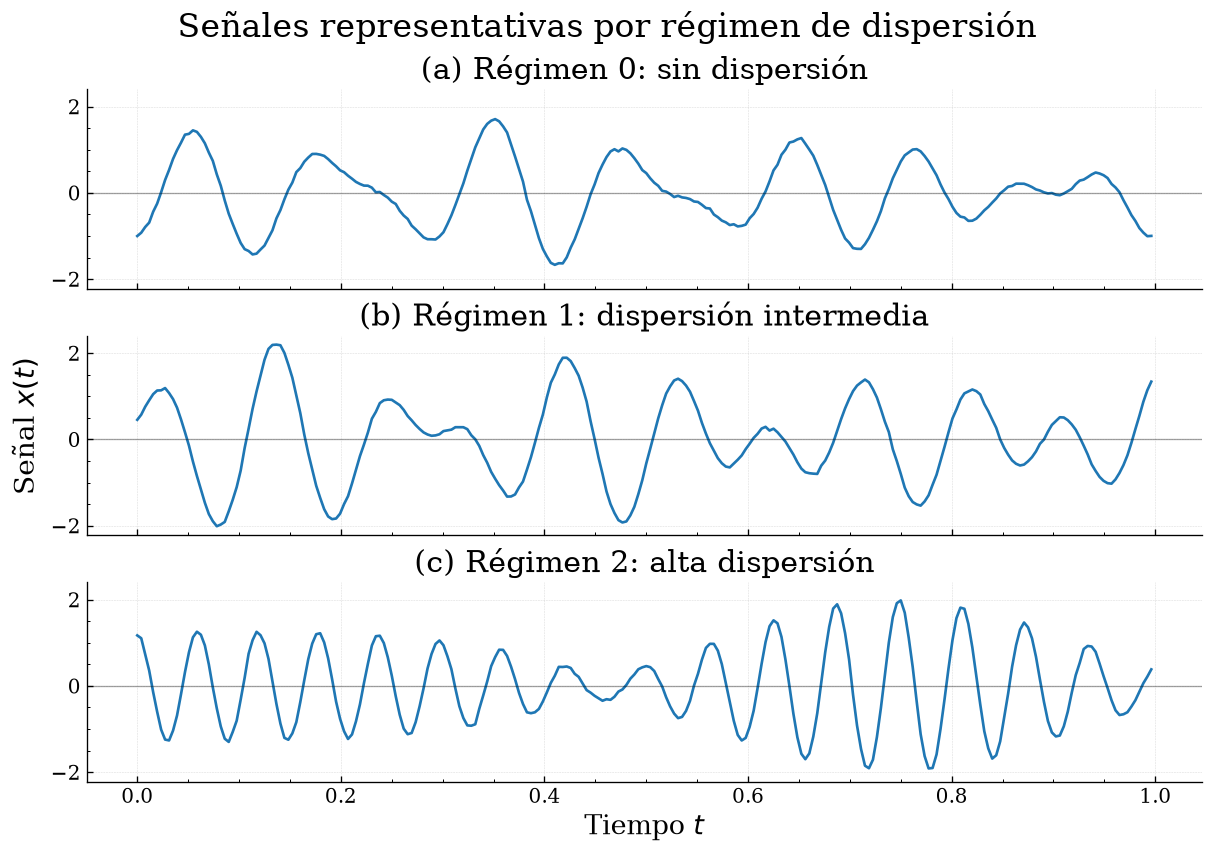

In [5]:
# Busca el índice de la primera señal correspondiente a cada régimen.
# Para cada valor r = 0, 1 y 2, np.where identifica las posiciones donde y == r.
# Luego se toma la primera posición encontrada con [0][0].
indices = [np.where(y == r)[0][0] for r in range(3)]

# Define los títulos que se mostrarán sobre cada gráfica.
# Cada título identifica el régimen físico representado.
titulos = [
    r"(a) Régimen 0: sin dispersión",
    r"(b) Régimen 1: dispersión intermedia",
    r"(c) Régimen 2: alta dispersión",
]

# Crea una figura con tres subgráficas organizadas verticalmente.
fig, axs = plt.subplots(
    3,                      # Número de filas.
    1,                      # Número de columnas.
    figsize=(10, 7),        # Tamaño total de la figura.
    sharex=True,            # Las tres gráficas comparten el eje horizontal.
    sharey=True,            # Las tres gráficas comparten el eje vertical.
    constrained_layout=True # Ajusta automáticamente los espacios.
)

# Recorre los tres regímenes y sus respectivos índices.
for r, idx in enumerate(indices):

    # Grafica la señal seleccionada para el régimen actual.
    # t contiene los valores del tiempo y X[idx] la amplitud de la señal.
    axs[r].plot(
        t,
        X[idx],
        linewidth=1.6
    )

    # Añade una línea horizontal en amplitud cero como referencia visual.
    axs[r].axhline(
        0,
        color="black",
        linewidth=0.8,
        alpha=0.35
    )

    # Asigna el título correspondiente a la subgráfica actual.
    axs[r].set_title(titulos[r])

    # Activa la cuadrícula usando la configuración definida en rcParams.
    axs[r].grid(True)

# Añade una sola etiqueta vertical para toda la figura.
fig.supylabel(r"Señal $x(t)$")

# Añade la etiqueta horizontal únicamente en la subgráfica inferior.
# Como los ejes están compartidos, esta etiqueta aplica a las tres gráficas.
axs[-1].set_xlabel(r"Tiempo $t$")

# Añade un título general que resume el contenido de la figura.
fig.suptitle(
    "Señales representativas por régimen de dispersión",
    fontsize=20
)

# Muestra la figura completa.
plt.show()

**Figura 1.** Señales temporales representativas $x(t)$ para los tres regímenes de dispersión. Se seleccionó una señal de cada etiqueta $y\in\{0,1,2\}$. La figura permite comparar cualitativamente la estructura temporal de las señales antes del entrenamiento de la red neuronal.

## 1. Capa Fourier

En esta sección se construye la capa Fourier que se utilizará para inicializar la primera capa de la red neuronal. Esta capa está formada por filas de senos y cosenos, tal como se pide en la rúbrica.

La matriz se denota por

$$
W_1 \in \mathbb{R}^{2K \times N},
$$

donde $N$ es el número de muestras temporales de cada señal. En este caso,

$$
N = 256.
$$

Se toma $K=20$, por lo que la capa Fourier tiene $2K=40$ filas.

Para cada frecuencia $k=1,\dots,K$, se incorporan las funciones

$$
\sin(2\pi k t)
$$

y

$$
\cos(2\pi k t).
$$

En la implementación, estas funciones se evalúan sobre los puntos temporales de cada señal para formar las filas de $W_1$.


### 1.1 Construcción de la capa Fourier

Como $K=20$ y $N=256$, la construcción de la capa Fourier produce una matriz

$$
W_1\in\mathbb{R}^{2K\times N}
=
\mathbb{R}^{40\times256}
$$

dada por

$$
W_1 =
\begin{bmatrix}
\sin(2\pi\cdot1\cdot \tau_0) & \cdots & \sin(2\pi\cdot1\cdot \tau_{255})\\
\vdots & \ddots & \vdots\\
\sin(2\pi\cdot20\cdot \tau_0) & \cdots & \sin(2\pi\cdot20\cdot \tau_{255})\\
\cos(2\pi\cdot1\cdot \tau_0) & \cdots & \cos(2\pi\cdot1\cdot \tau_{255})\\
\vdots & \ddots & \vdots\\
\cos(2\pi\cdot20\cdot \tau_0) & \cdots & \cos(2\pi\cdot20\cdot \tau_{255})
\end{bmatrix}.
$$

Aquí $\tau_j=j/N$ corresponde al tiempo normalizado en el que se evalúan las funciones seno y coseno para construir las filas de la capa Fourier.

In [6]:
# Define el número de frecuencias que se usarán en la base de Fourier.
K = 20

# Obtiene el número de muestras temporales de cada señal.
# Como X tiene forma (24, 256), X.shape[1] es igual a 256.
N = X.shape[1]


# Construye un vector de tiempo normalizado:
# tau = [0/N, 1/N, 2/N, ..., (N-1)/N].
# Este vector contiene N puntos distribuidos en el intervalo [0, 1).
tau = jnp.arange(N) / N

# Construye el vector con los números de frecuencia:
# k = [1, 2, 3, ..., K].
k = jnp.arange(1, K + 1)


# Construye las K filas asociadas a las funciones seno.
# k[:, None] cambia la forma de k de (K,) a (K, 1).
# tau[None, :] cambia la forma de tau de (N,) a (1, N).
# Mediante broadcasting se obtiene una matriz de forma (K, N),
# donde cada fila corresponde a sin(2πkτ) para una frecuencia distinta.
W1_sin = jnp.sin(2 * jnp.pi * k[:, None] * tau[None, :])


# Construye las K filas asociadas a las funciones coseno.
# El resultado también es una matriz de forma (K, N),
# donde cada fila corresponde a cos(2πkτ).
W1_cos = jnp.cos(2 * jnp.pi * k[:, None] * tau[None, :])



# Une verticalmente las matrices de senos y cosenos.
# Las primeras K filas corresponden a los senos y las siguientes
# K filas corresponden a los cosenos.
# Por tanto, W1 tiene forma (2K, N) = (40, 256).
W1 = jnp.vstack([W1_sin, W1_cos])


#Dimensiones de la matriz Fourier construida.
print("W1.shape =", W1.shape)

#Número de muestras temporales de cada señal.
print("N =", N)

W1.shape = (40, 256)
N = 256


### 1.2 Verificación frente a `np.fft` (Transformada Discreta de Fourier)

Inicialmente se selecciona una señal del conjunto de datos y se calcula la salida de la capa Fourier:

$$
z = W_1x.
$$

Este paso permite verificar las dimensiones de la operación. Como $x\in\mathbb{R}^{256}$ y $W_1\in\mathbb{R}^{40\times256}$, la salida debe cumplir

$$
z\in\mathbb{R}^{40}.
$$

In [7]:
# Seleccionar primera señal del conjunto de datos
# X[0] tiene 256 muestras temporales y se convierte en un arreglo de JAX.
x = jnp.array(X[0])



# Aplicar la capa Fourier----
# Multiplica la matriz Fourier W1 por la señal x.
# W1 tiene forma (40, 256) y x tiene forma (256,),
# por lo que el resultado z tiene forma (40,).
z = W1 @ x


#Dimensión de la señal seleccionada.
print("x.shape =", x.shape)

#Dimensión de la salida de la capa Fourier.
print("z.shape =", z.shape)

x.shape = (256,)
z.shape = (40,)


In [8]:
# Muestra los primeros K coeficientes de z.
# Estos coeficientes corresponden a las proyecciones de la señal
# sobre las funciones seno de frecuencias k = 1, ..., K.
print("Coeficientes asociados a las funciones seno:")
print(z[:K])

# Muestra los últimos K coeficientes de z.
# Estos coeficientes corresponden a las proyecciones de la señal
# sobre las funciones coseno de frecuencias k = 1, ..., K.
print("\nCoeficientes asociados a las funciones coseno:")
print(z[K:])

Coeficientes asociados a las funciones seno:
[ 4.47720408e-01  3.34008038e-01  1.08840138e-01  8.68191719e-01
  8.13249588e-01 -5.50313830e-01 -4.36632614e+01  5.54417953e+01
  3.17084675e+01  1.12890526e+02 -4.41303711e+01 -1.75283127e+01
 -1.09743843e+01 -7.88773918e+00 -6.14795303e+00 -5.41703176e+00
 -4.60955524e+00 -3.61072922e+00 -2.62812662e+00 -3.18041635e+00]

Coeficientes asociados a las funciones coseno:
[ 7.8463984e-01  8.2724839e-01  1.0779440e+00  1.3935046e+00
  2.2512667e+00  4.7395577e+00  9.8476761e+01  1.3783740e+01
  3.9818048e-02  3.6207123e+00 -3.0463669e+00 -1.3111539e+00
 -1.2671571e+00 -1.2948383e+00 -3.1015587e-01 -6.5350223e-01
 -9.9100471e-01 -8.4934640e-01 -1.0859661e+00 -9.9274158e-02]


Los primeros K valores corresponden a las proyecciones sobre funciones seno, mientras que los últimos K corresponden a las proyecciones sobre funciones coseno. Para verificar que estos coeficientes coinciden con una representación de Fourier, se comparan a continuación con `np.fft.rfft`.




La Transformada Discreta de Fourier entrega coeficientes complejos. Su parte real está asociada a las funciones coseno, mientras que los coeficientes seno de la capa Fourier coinciden con el negativo de la parte imaginaria de `np.fft.rfft`, debido a la convención exponencial usada por NumPy.

In [9]:
# Calcula la Transformada Discreta de Fourier de la señal x.
X_fft = np.fft.rfft(np.array(x))

# Se toman las primeras K frecuencias no nulas: k = 1, ..., K
fft_k = X_fft[1:K + 1]

# Coeficientes obtenidos por la capa Fourier---
# W1 está organizado como [senos, cosenos]

# Aplica nuevamente la capa Fourier a la señal x.
# El resultado se convierte a un arreglo de NumPy
# para facilitar la comparación con np.fft.rfft.
z = np.array(W1 @ x)


# Extrae los primeros K coeficientes.
# Estos corresponden a las proyecciones sobre las funciones seno.
z_sin = z[:K]


# Extrae los últimos K coeficientes.
# Estos corresponden a las proyecciones sobre las funciones coseno.
z_cos = z[K:]

# Comparación con la FFT--

# Muestra los coeficientes coseno calculados mediante la capa Fourier.
print("Coeficientes coseno de W1x:")
print(np.round(z_cos, 3))


# Muestra la parte real de los coeficientes complejos obtenidos con la FFT.
print("\nParte real de la FFT:")
print(np.round(np.real(fft_k), 3))

# Muestra los coeficientes seno calculados mediante la capa Fourier.
print("\nCoeficientes seno de W1x:")
print(np.round(z_sin, 3))


# Muestra el negativo de la parte imaginaria de la FFT.
# El signo negativo aparece por la convención exponencial utilizada
# en la definición de la Transformada Discreta de Fourier de NumPy.
print("\nNegativo de la parte imaginaria de la FFT:")
print(np.round(-np.imag(fft_k), 3))

Coeficientes coseno de W1x:
[ 7.8500e-01  8.2700e-01  1.0780e+00  1.3940e+00  2.2510e+00  4.7400e+00
  9.8477e+01  1.3784e+01  4.0000e-02  3.6210e+00 -3.0460e+00 -1.3110e+00
 -1.2670e+00 -1.2950e+00 -3.1000e-01 -6.5400e-01 -9.9100e-01 -8.4900e-01
 -1.0860e+00 -9.9000e-02]

Parte real de la FFT:
[ 7.8500e-01  8.2700e-01  1.0780e+00  1.3940e+00  2.2510e+00  4.7400e+00
  9.8477e+01  1.3784e+01  4.0000e-02  3.6210e+00 -3.0470e+00 -1.3110e+00
 -1.2670e+00 -1.2950e+00 -3.1000e-01 -6.5400e-01 -9.9100e-01 -8.4900e-01
 -1.0860e+00 -9.9000e-02]

Coeficientes seno de W1x:
[ 4.48000e-01  3.34000e-01  1.09000e-01  8.68000e-01  8.13000e-01
 -5.50000e-01 -4.36630e+01  5.54420e+01  3.17080e+01  1.12891e+02
 -4.41300e+01 -1.75280e+01 -1.09740e+01 -7.88800e+00 -6.14800e+00
 -5.41700e+00 -4.61000e+00 -3.61100e+00 -2.62800e+00 -3.18000e+00]

Negativo de la parte imaginaria de la FFT:
[ 4.4800e-01  3.3400e-01  1.0900e-01  8.6800e-01  8.1300e-01 -5.5000e-01
 -4.3663e+01  5.5442e+01  3.1708e+01  1.1289e+02 -

Los resultados muestran que los coeficientes asociados a las funciones coseno coinciden con la parte real de la Transformada Discreta de Fourier. Por otro lado, los coeficientes asociados a las funciones seno coinciden con el negativo de la parte imaginaria.

Esta diferencia de signo se debe a la convención utilizada en la definición compleja de la transformada, donde aparece el término $e^{-2\pi i k\tau}$. En consecuencia, la comparación confirma que la salida de la capa Fourier reproduce correctamente los coeficientes trigonométricos asociados a las primeras $K$ frecuencias no nulas de la Transformada Discreta de Fourier.

### 1.3 Energía media del dataset

La energía media del conjunto de datos se calcula como

$$
\frac{1}{24\cdot256}\sum_{i=1}^{24}\sum_{j=1}^{256} X_{ij}^{2}.
$$

Este valor resume la magnitud cuadrática promedio de las señales y permite caracterizar globalmente la escala de amplitud del conjunto de datos.

In [10]:
# Eleva al cuadrado cada valor de la matriz X y calcula el promedio
# sobre todas las señales y todas sus muestras temporales.
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.696


## 2. Entrenamiento y reconstrucción

Una vez construida y verificada la capa Fourier, el siguiente paso consiste en implementar y entrenar la red neuronal encargada de reconstruir las señales temporales del conjunto de datos.

La red recibe una señal

$$
x\in\mathbb{R}^{256}
$$

y produce una reconstrucción

$$
\hat{x}\in\mathbb{R}^{256}.
$$

La arquitectura utilizada tiene dos capas lineales separadas por una función de activación hiperbólica $\tanh$:

$$
\hat{x}=W_2\,\tanh(W_1x).
$$

La primera capa transforma la señal de entrada en una representación de dimensión $2K=40$, mientras que la segunda capa utiliza dicha representación para reconstruir la señal original.

Se comparan dos formas de inicializar la primera capa $W_1$:

- inicialización mediante la capa Fourier construida previamente;
- inicialización aleatoria.

En ambos casos, los parámetros se entrenan mediante descenso por gradiente.

### 2.1 Implementación de la red neuronal en JAX

In [11]:
# ============================
# Inicialización de parámetros
# ============================

def init_params(key, W1_init):
    """
    Inicializa los parámetros entrenables de la red neuronal.

    Parámetros
    ----------
    key:
        Clave aleatoria de JAX utilizada para generar los pesos iniciales.

    W1_init:
        Matriz inicial de la primera capa, con forma (2K, N).
        Puede corresponder a la inicialización Fourier o a una
        inicialización aleatoria.

    Retorna
    -------
    params:
        Diccionario que contiene las matrices W1 y W2.

    """
    # Divide la clave aleatoria original en dos claves independientes.
    # Esto permite generar números aleatorios sin reutilizar la misma clave.
    key1, key2 = jax.random.split(key)
    
    # Agrupa los parámetros de la red en un diccionario.
    params = {

        # Inicializa la primera capa con la matriz recibida como argumento.
        # Su dimensión es (2K, N) = (40, 256).
        "W1": W1_init,

        # Inicializa la segunda capa con valores aleatorios pequeños.
        # La matriz W2 transforma el vector oculto de dimensión 2K
        # en una reconstrucción de dimensión N.
        # Su forma es (N, 2K) = (256, 40).
        "W2": 0.01 * jax.random.normal(key1, (N, 2 * K))
    }
    
    # Devuelve el diccionario con los parámetros iniciales de la red.
    return params

In [12]:
def forward(params, x):
    """
    Realiza la propagación hacia adelante de la red neuronal.

    Parámetros
    ----------
    params:
        Diccionario que contiene las matrices W1 y W2.

    x:
        Señal de entrada con dimensión (N,) = (256,).

    Retorna
    -------
    x_hat:
        Reconstrucción de la señal de entrada, con dimensión (N,).
    """

    # Extrae la matriz de pesos de la primera capa.
    W1 = params["W1"]
    # Extrae la matriz de pesos de la segunda capa.
    W2 = params["W2"]


    # Proyecta la señal x sobre las 2K funciones de la primera capa.
    # W1 tiene forma (2K, N) y x tiene forma (N,),
    # por lo que W1 @ x produce un vector de forma (2K,).
    # Luego se aplica la función de activación tanh elemento a elemento.
    h = jnp.tanh(W1 @ x)

    # Reconstruye la señal original a partir de la representación oculta h.
    # W2 tiene forma (N, 2K) y h tiene forma (2K,),
    # por lo que W2 @ h produce un vector de forma (N,).
    x_hat = W2 @ h

    #señal reconstruida
    return x_hat

La función de pérdida se define como el error cuadrático medio entre la señal original y la reconstrucción:

$$
\mathcal{L}(x,\hat{x})=\frac{1}{N}\|\hat{x}-x\|^2.
$$

In [13]:
def loss(params, x):

    """
    Calcula el error cuadrático medio entre la señal original
    y la reconstrucción producida por la red neuronal.

    Parámetros
    ----------
    params:
        Diccionario que contiene los parámetros entrenables W1 y W2.

    x:
        Señal original de entrada con dimensión (N,) = (256,).

    Retorna
    -------
    mse:
        Error cuadrático medio entre x y su reconstrucción.
    """

    # Obtiene la reconstrucción de la señal mediante la red neuronal.
    x_hat = forward(params, x)

    # Calcula la diferencia entre la señal reconstruida y la señal original,
    # eleva cada error al cuadrado y promedia sobre las N muestras temporales.
    # Este cálculo equivale a (1/N) ||x_hat - x||².
    return jnp.mean((x_hat - x) ** 2)

Para actualizar los parámetros se utiliza descenso por gradiente. En cada paso se calculan los gradientes de la pérdida con respecto a los parámetros de la red y se actualizan usando una tasa de aprendizaje $\eta=0.1$.

In [14]:
# Compila la función update con XLA mediante JAX.
# Esto permite que las llamadas repetidas a la función sean más rápidas,
# ya que JAX traduce las operaciones numéricas a una versión optimizada.
@jax.jit
def update(params, x, lr):
    """
    Realiza un paso de descenso por gradiente sobre una señal.

    Parámetros
    ----------
    params:
        Diccionario con los parámetros entrenables W1 y W2.

    x:
        Señal utilizada para calcular la pérdida.

    lr:
        Tasa de aprendizaje.

    Retorna
    -------
    params:
        Parámetros actualizados.
    """

    # Calcula automáticamente el gradiente de la función loss
    # con respecto al primer argumento, es decir, params.
    # El resultado conserva la misma estructura de diccionario que params.
    grads = jax.grad(loss)(params, x)


    # Aplica una función a cada par de elementos correspondiente
    # dentro de las estructuras params y grads.
    params = jax.tree_util.tree_map(

        # Actualiza cada parámetro p usando su gradiente g
        # mediante la regla de descenso por gradiente:
        # p_nuevo = p - lr * g.
        lambda p, g: p - lr * g,

        # Primera estructura recorrida: parámetros actuales.
        params,

        # Segunda estructura recorrida: gradientes de los parámetros.
        grads
    )
    # Devuelve el diccionario con los parámetros actualizados.
    return params


def train(params, X_train, num_iters=4000, lr=0.1):
    """
    Entrena la red neuronal y registra la pérdida media
    al final de cada iteración completa.
    """

    # Crea una lista para almacenar la pérdida media
    # obtenida al final de cada iteración.
    losses = []

    # Convierte el conjunto de entrenamiento en un arreglo de JAX.
    X_train = jnp.array(X_train)

    # Repite el entrenamiento durante num_iters iteraciones.
    for i in range(num_iters):

        # Actualiza los parámetros utilizando una vez
        # cada señal del conjunto de entrenamiento.
        for x in X_train:
            params = update(params, x, lr)

        # Inicializa el acumulador de pérdida.
        total_loss = 0.0

        # Evalúa todas las señales usando el mismo estado final
        # de los parámetros correspondiente a esta iteración.
        for x in X_train:
            total_loss += loss(params, x)

        # Calcula la pérdida media del conjunto de entrenamiento.
        mean_loss = total_loss / X_train.shape[0]

        # Guarda la pérdida media de la iteración actual.
        losses.append(mean_loss)

    # Devuelve los parámetros entrenados y el historial de pérdidas.
    return params, jnp.array(losses)

### 2.2 Entrenamiento con inicialización Fourier y aleatoria

Se entrenan dos redes con la misma arquitectura y los mismos hiperparámetros. La única diferencia entre ellas es la inicialización de la primera capa $W_1$.

En el primer caso, $W_1$ se inicializa con la matriz Fourier construida en la sección anterior. En el segundo caso, $W_1$ se inicializa de forma aleatoria.

El entrenamiento se realiza sobre todo el conjunto de datos, es decir, sobre señales de los tres regímenes de dispersión.

In [15]:
# Inicialización Fourier y aleatoria

# Crea una clave que se utilizará para inicializar W2
# de la misma forma en ambas redes.
key_params = jax.random.PRNGKey(42)

# Crea una clave independiente para generar la matriz W1 aleatoria.
key_random = jax.random.PRNGKey(43)

# Inicializa la red Fourier.
# La primera capa comienza con la matriz Fourier W1.
params_fourier = init_params(
    key_params,
    W1
)

# Construye la matriz aleatoria para la primera capa.
W1_random = 0.01 * jax.random.normal(
    key_random,
    (2 * K, N)
)

# Inicializa la red aleatoria usando la misma clave key_params.
# De esta manera, W2 comienza exactamente igual en ambas redes
# y la única diferencia está en W1.
params_random = init_params(
    key_params,
    W1_random
)

# Entrenamiento

#Num total iteraciones de entrenamiento.
num_iters = 4000

#Tasa de aprendizaje utilizada en el descenso por gradiente.
lr = 0.1

# Entrena la red cuya primera capa fue inicializada con la base Fourier.
# La función devuelve los parámetros entrenados y el historial de pérdidas.c
params_fourier_trained, losses_fourier = train(params_fourier, X, num_iters, lr)


# Entrena la red cuya primera capa fue inicializada aleatoriamente.
# Se utiliza el mismo conjunto de datos y los mismos hiperparámetros
# para que la comparación dependa únicamente de la inicialización de W1.
params_random_trained, losses_random = train(params_random, X, num_iters, lr)

# Pérdida correspondiente a la última iteración de la red inicializada con Fourier.
print("Loss final Fourier:", losses_fourier[-1])

# Pérdida correspondiente a la última iteraciónde la red inicializada de forma aleatoria.
print("Loss final aleatoria:", losses_random[-1])

Loss final Fourier: 9.401295e-12
Loss final aleatoria: 1.4726567e-11


### 2.3 Reconstrucción final por régimen

Una vez entrenadas ambas redes, se comparan las señales reconstruidas con las señales originales. Para visualizar el resultado, se selecciona una señal representativa de cada uno de los tres regímenes.

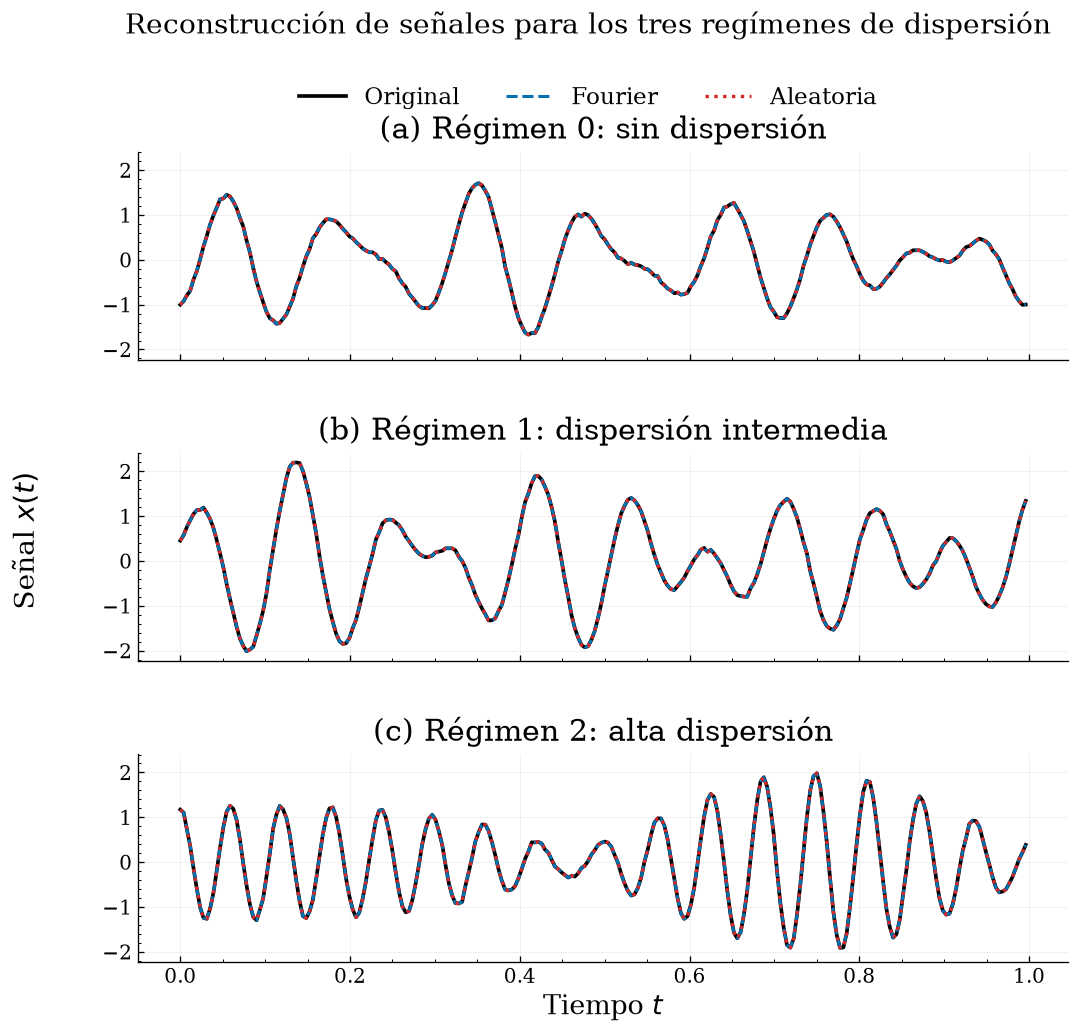

In [16]:
# Señales reconstruidas

# Reconstruye todas las señales del conjunto de datos con la red
# cuya primera capa fue inicializada con la matriz Fourier.
# Para cada señal x en X, se aplica la función forward con los
# parámetros ya entrenados.
X_fourier = jnp.array([forward(params_fourier_trained, x) for x in X])

# Reconstruye todas las señales del conjunto de datos con la red
# cuya primera capa fue inicializada aleatoriamente.
X_random = jnp.array([forward(params_random_trained, x) for x in X])

# Busca el índice de la primera señal correspondiente a cada régimen.
# Se obtiene una señal representativa para y = 0, y = 1 y y = 2.
indices = [np.where(y == r)[0][0] for r in range(3)]

#Títulos de las tres subgráficas.
titulos = [
    r"(a) Régimen 0: sin dispersión",
    r"(b) Régimen 1: dispersión intermedia",
    r"(c) Régimen 2: alta dispersión",
]

# Colores usados para diferenciar la señal original
# y las reconstrucciones obtenidas con cada inicialización.
color_original = "black"
color_fourier = "#0072B2"
color_random = "#D62728"

# Crea una figura con tres subgráficas organizadas verticalmente.
fig, axs = plt.subplots(
    3, #filas
    1, #columnas
    figsize=(10, 9),#tamaño total de la figura
    sharex=True, #subrgáficas comparten eje horizontal
    sharey=True, #subgráficas comparten eje vertical
)

# Recorre simultáneamente cada eje, el índice de la señal
# representativa y el título correspondiente.
for ax, idx, titulo in zip(axs, indices, titulos):

    # Grafica la señal original con línea continua.
    ax.plot(t, X[idx], color=color_original, linewidth=2.2, label="Original")

    # Grafica la reconstrucción obtenida con inicialización Fourier.
    ax.plot(t, X_fourier[idx], "--", color=color_fourier, linewidth=1.8, label="Fourier")

    # Grafica la reconstrucción obtenida con inicialización aleatoria.
    ax.plot(t, X_random[idx], ":", color=color_random, linewidth=2.0, label="Aleatoria")

     # Asigna el título correspondiente al régimen mostrado.
    ax.set_title(titulo, pad=8)


    # Activa la cuadrícula usando la configuración definida en rcParams.
    ax.grid(True)


# Añade una sola etiqueta vertical para toda la figura.
# Esto evita repetir x(t) en las tres subgráficas.
fig.supylabel(r"Señal $x(t)$")

# Añade la etiqueta horizontal únicamente en la subgráfica inferior.
# Como el eje horizontal está compartido, esta etiqueta aplica a las tres.
axs[-1].set_xlabel(r"Tiempo $t$")


# Obtiene los objetos y textos de la leyenda de la primera subgráfica.
handles, labels = axs[0].get_legend_handles_labels()

# Crea una única leyenda general para toda la figura.
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94)
)

# Añade el título general de la figura.
fig.suptitle(
    r"Reconstrucción de señales para los tres regímenes de dispersión",
    y=0.99
)

# Ajusta el espacio superior para la leyenda y el título,
# además de aumentar la separación entre las subgráficas.
fig.subplots_adjust(
    top=0.86,
    hspace=0.45
)


plt.show()

**Figura 2.** Comparación entre las señales originales y las reconstrucciones finales obtenidas con inicialización Fourier y con inicialización aleatoria. Se muestra una señal representativa de cada régimen de dispersión. La superposición de las curvas indica que ambas redes logran reconstruir adecuadamente las señales después del entrenamiento.

### 2.4 Error relativo de reconstrucción

Como medida cuantitativa del desempeño de la red, se calcula el error relativo de reconstrucción definido por

$$
\varepsilon=
\frac{\|\hat{x}-x\|}{\|x\|},
$$

donde $x$ corresponde a la señal original y $\hat{x}$ a la reconstrucción obtenida por la red.

Este indicador permite comparar objetivamente la calidad de la reconstrucción para ambas estrategias de inicialización en cada régimen de dispersión.

In [17]:
def relative_error(x, x_hat):
    # Calcula la norma del error de reconstrucción y la divide
    # entre la norma de la señal original.
    return jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x)


# Crea una lista vacía para almacenar el error relativo
# de cada señal reconstruida con inicialización Fourier.
errors_fourier = []

# Crea una lista vacía para almacenar el error relativo
# de cada señal reconstruida con inicialización aleatoria.
errors_random = []

# Recorre todas las señales del conjunto de datos.
for x in X:
    # Convierte la señal actual en un arreglo de JAX.
    x = jnp.array(x)


    # Reconstruye la señal usando la red entrenada
    # con inicialización Fourier.
    x_fourier = forward(params_fourier_trained, x)

    # Reconstruye la señal usando la red entrenada
    # con inicialización aleatoria.
    x_random = forward(params_random_trained, x)

    # Calcula el error relativo de la reconstrucción tanto para Fourieer como aleatoria
    # y lo convierte a float de Python antes de almacenarlo.

    errors_fourier.append(float(relative_error(x, x_fourier)))
    errors_random.append(float(relative_error(x, x_random)))

# Recorre los tres regímenes de dispersión: 0, 1 y 2.
for r in range(3):

    # Construye una máscara booleana que identifica
    # las señales pertenecientes al régimen actual.
    idx = (y == r)

    # Convierte la lista de errores Fourier y aleatoria en arreglos de NumPy,
    # selecciona los errores del régimen actual y calcula su promedio.
    ef = np.mean(np.array(errors_fourier)[idx])
    er = np.mean(np.array(errors_random)[idx])

    # Imprime el número del régimen analizado.
    print(f"Régimen {r}")
    # Imprime el error relativo medio de la red
    print(f"  Fourier   : {ef:.3e}")
    print(f"  Aleatoria : {er:.3e}")
    print()

Régimen 0
  Fourier   : 3.523e-06
  Aleatoria : 3.984e-06

Régimen 1
  Fourier   : 3.749e-06
  Aleatoria : 4.231e-06

Régimen 2
  Fourier   : 4.520e-06
  Aleatoria : 6.869e-06



Los errores relativos obtenidos son del orden de $10^{-6}$ para ambas estrategias de inicialización, lo que confirma la alta precisión de las reconstrucciones alcanzadas por la red. En los tres regímenes de dispersión, la inicialización basada en Fourier presenta errores relativos ligeramente menores que la inicialización aleatoria.

## 3. Comparación de inicializaciones

En esta sección se compara el efecto de inicializar la primera capa de la red neuronal con la base de Fourier frente a una inicialización aleatoria.

Aunque ambas redes tienen la misma arquitectura y se entrenan con los mismos hiperparámetros, el punto de partida de la primera capa $W_1$ es diferente. Por esta razón, se analiza la evolución de la pérdida durante el entrenamiento y la velocidad con la que cada inicialización reduce el error.

### 3.1 Evolución de la pérdida durante 4000 iteraciones

Para estudiar el comportamiento de ambas inicializaciones, se registra el valor de la función de pérdida en cada iteración del entrenamiento. El entrenamiento se realiza durante 4000 iteraciones con tasa de aprendizaje $\eta=0.1$, usando las señales de los tres regímenes.

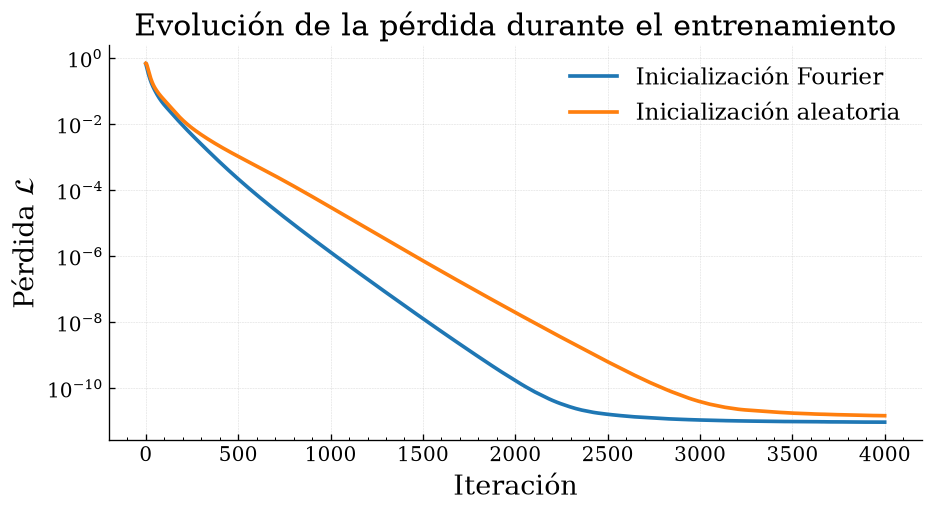

In [18]:
# Crea una figura y un eje para representar la evolución de la pérdida.
# figsize define el tamaño de la figura en pulgadas.
fig, ax = plt.subplots(figsize=(8, 4.5))


# Grafica la pérdida obtenida en cada iteración por la red
# inicializada con la matriz Fourier y aleatoria respectivamente.
ax.plot(losses_fourier, linewidth=2.2, label="Inicialización Fourier")
ax.plot(losses_random, linewidth=2.2, label="Inicialización aleatoria")

# Asigna un título descriptivo a la figura.
ax.set_title(r"Evolución de la pérdida durante el entrenamiento")

# Etiqueta el eje horizontal como el número de iteración.
ax.set_xlabel(r"Iteración")

# Etiqueta el eje vertical con la función de pérdida utilizada.
ax.set_ylabel(r"Pérdida $\mathcal{L}$")


ax.set_yscale("log")

# Activa la cuadrícula usando la configuración definida en rcParams.
ax.grid(True)

# Muestra la leyenda que identifica ambas inicializaciones.
# frameon=False elimina el borde de la leyenda.
ax.legend(frameon=False)

# Ajusta automáticamente los márgenes para evitar que
# los títulos y las etiquetas queden recortados.
plt.tight_layout()
plt.show()

**Figura 3.** Evolución de la pérdida $\mathcal{L}$ en escala logarítmica durante las 4000 iteraciones de entrenamiento. Se comparan las redes inicializadas con la capa Fourier y con una matriz aleatoria.

In [19]:
#pérdida registrada en la última iteración para red inicialziada con Fourier y aleatoria respectivamente.
print("Loss final Fourier:", losses_fourier[-1])
print("Loss final aleatoria:", losses_random[-1])

Loss final Fourier: 9.401295e-12
Loss final aleatoria: 1.4726567e-11


La figura muestra que ambas inicializaciones logran reducir la pérdida de reconstrucción hasta valores muy pequeños. La escala logarítmica permite observar con mayor claridad la disminución del error durante el entrenamiento.

El valor final de la pérdida fue

$$
\mathcal{L}_{\mathrm{Fourier}} = 9.40\times10^{-12},
$$

mientras que para la inicialización aleatoria fue

$$
\mathcal{L}_{\mathrm{aleatoria}} = 1.47\times10^{-11}.
$$

Aunque ambos errores finales son extremadamente pequeños, la inicialización Fourier alcanza una pérdida final ligeramente menor y, además, converge más rápido durante las primeras iteraciones.

### 3.2 Iteraciones necesarias para alcanzar error relativo menor que 0.1

Además de comparar la pérdida final, se mide cuántas iteraciones necesita cada inicialización para alcanzar un error relativo menor que $0.1$. Esta medida permite comparar la velocidad de convergencia de ambas estrategias.

In [20]:
#Umbral de error relativo que se desea alcanzar.
threshold = 0.1


# Convierte la pérdida cuadrática media de cada iteración
# en una estimación del error relativo global.
# Se divide entre la energía media del conjunto de datos
# y luego se toma la raíz cuadrada.
rel_errors_fourier = np.sqrt(np.array(losses_fourier) / energia_media)

# Realiza la misma conversión para la red
# inicializada de forma aleatoria.
rel_errors_random = np.sqrt(np.array(losses_random) / energia_media)

def first_below_threshold(errors, threshold=0.1):
    """
    Encuentra la primera iteración en la que el error
    es menor que el umbral especificado.
    """

    # Convierte la secuencia de errores en un arreglo de NumPy.
    errors = np.array(errors)

    # Obtiene los índices donde el error es menor que el umbral.
    idx = np.where(errors < threshold)[0]

    # Devuelve el primer índice encontrado.
    # Si ningún error es menor que el umbral, devuelve None.
    return int(idx[0]+1) if len(idx) > 0 else None


# Busca la primera iteración en la que la inicialización Fourier y la aleatoria
# alcanzan un error relativo menor que 0.1.
iter_fourier = first_below_threshold(rel_errors_fourier, threshold)
iter_random = first_below_threshold(rel_errors_random, threshold)

#resultados
print(
    "Inicialización Fourier  :",
    f"{iter_fourier} iteraciones" if iter_fourier is not None else "no alcanzó el umbral"
)

print(
    "Inicialización aleatoria:",
    f"{iter_random} iteraciones" if iter_random is not None else "no alcanzó el umbral"
)

Inicialización Fourier  : 221 iteraciones
Inicialización aleatoria: 260 iteraciones


La comparación del número de iteraciones necesarias para alcanzar el umbral $\varepsilon < 0.1$ permite evaluar no solo la precisión final, sino también la rapidez del aprendizaje. Si una inicialización alcanza este umbral en menos iteraciones, entonces mejora más rápido durante las etapas iniciales del entrenamiento.

### 3.3 Análisis del régimen 0: sin dispersión

El enunciado solicita prestar especial atención al régimen 0, correspondiente al caso sin dispersión. Para ello, la red se entrena nuevamente utilizando únicamente las señales con etiqueta $y=0$.

En este régimen, las señales presentan una estructura espectral dominada por frecuencias más bajas, por lo que resulta natural analizar si una inicialización basada en funciones de Fourier proporciona una convergencia más rápida que una inicialización aleatoria.

In [21]:
# Selecciona únicamente las señales cuya etiqueta corresponde
# al régimen 0, es decir, al caso sin dispersión.
X_reg0 = X[y == 0]

# Crea una clave común para inicializar W2
# de la misma forma en ambas redes del régimen 0.
key_params_reg0 = jax.random.PRNGKey(123)

# Crea una clave independiente para generar W1 aleatoria.
key_random_reg0 = jax.random.PRNGKey(124)

# Inicializa la red del régimen 0 con la matriz Fourier W1.
params_fourier_reg0 = init_params(
    key_params_reg0,
    W1
)

# Genera una matriz aleatoria de forma (2K, N) = (40, 256)
# para inicializar la primera capa de la segunda red.
# El factor 0.01 mantiene pequeños los valores iniciales.
W1_random_reg0 = 0.01 * jax.random.normal(
    key_random_reg0,
    (2 * K, N)
)

# Inicializa la red aleatoria usando la misma clave key_params_reg0.
# De esta manera, W2 comienza igual en ambas redes
# y la única diferencia entre ellas está en W1.
params_random_reg0 = init_params(
    key_params_reg0,
    W1_random_reg0
)

# Entrena la red inicializada con Fourier usando únicamente
# las señales pertenecientes al régimen 0.
params_fourier_reg0_trained, losses_fourier_reg0 = train(
    params_fourier_reg0,
    X_reg0,
    num_iters,
    lr
)

# Entrena la red inicializada aleatoriamente usando únicamente
# las señales pertenecientes al régimen 0.
params_random_reg0_trained, losses_random_reg0 = train(
    params_random_reg0,
    X_reg0,
    num_iters,
    lr
)

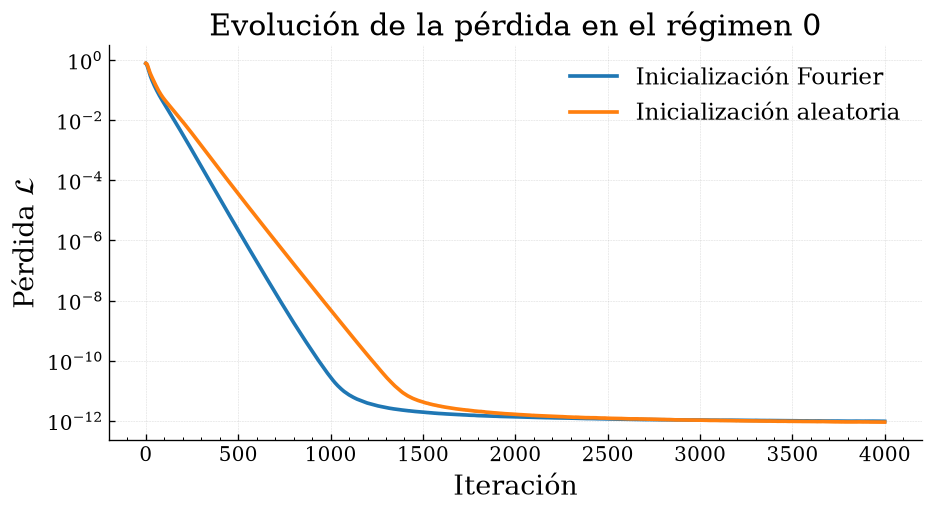

In [29]:
# Crea una figura y un eje para comparar la evolución
# de la pérdida de ambas inicializaciones en el régimen 0.
fig, ax = plt.subplots(figsize=(8, 4.5))

# Grafica la pérdida obtenida en cada iteración por la red
# inicializada con la matriz Fourier y aleatoria respectivamente.
ax.plot(losses_fourier_reg0, linewidth=2.2, label="Inicialización Fourier")
ax.plot(losses_random_reg0, linewidth=2.2, label="Inicialización aleatoria")

# Asigna un título descriptivo a la figura.
ax.set_title(r"Evolución de la pérdida en el régimen 0")
#Etiquetas
ax.set_xlabel(r"Iteración")
ax.set_ylabel(r"Pérdida $\mathcal{L}$")

#escala para eje
ax.set_yscale("log")


# Activa la cuadrícula usando la configuración definida en rcParams.
ax.grid(True)
# Muestra la leyenda que identifica ambas inicializaciones.
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**Figura 4.** Evolución de la pérdida para las señales del régimen 0, correspondiente al caso sin dispersión. Se comparan las inicializaciones Fourier y aleatoria bajo las mismas condiciones de entrenamiento.

En el régimen 0, la inicialización Fourier resulta especialmente natural porque las señales se componen de frecuencias bien definidas. Por ello, iniciar la primera capa con funciones seno y coseno puede facilitar que la red encuentre una representación adecuada desde las primeras iteraciones.

In [23]:
#Pérdida final de las redes inicializadas con Fourier
# y de forma aleatoria, entrenadas únicamente con el régimen 0.
print("Loss final Fourier régimen 0:", losses_fourier_reg0[-1])
print("Loss final aleatoria régimen 0:", losses_random_reg0[-1])

Loss final Fourier régimen 0: 9.662223e-13
Loss final aleatoria régimen 0: 9.0902974e-13


In [24]:
# Calcula la energía media de las señales pertenecientes al régimen 0.
energia_reg0 = (X_reg0**2).mean()

# Convierte las pérdidas del régimen 0 en estimaciones del error relativo
# para las inicializaciones Fourier y aleatoria, respectivamente.
rel_errors_fourier_reg0 = np.sqrt(np.array(losses_fourier_reg0) / energia_reg0)
rel_errors_random_reg0 = np.sqrt(np.array(losses_random_reg0) / energia_reg0)

# Determina la primera iteración en la que cada inicialización alcanza
# un error relativo menor que el umbral definido.
iter_fourier_reg0 = first_below_threshold(rel_errors_fourier_reg0, threshold)
iter_random_reg0 = first_below_threshold(rel_errors_random_reg0, threshold)


#Número de iteraciones requerido por cada inicialización
# para alcanzar el umbral en el régimen 0.
print("Iteraciones Fourier régimen 0:", iter_fourier_reg0)
print("Iteraciones aleatoria régimen 0:", iter_random_reg0)

Iteraciones Fourier régimen 0: 166
Iteraciones aleatoria régimen 0: 209


Los resultados del régimen 0 permiten observar con mayor detalle la diferencia de velocidad entre ambas inicializaciones. En particular, la inicialización Fourier alcanza $\varepsilon < 0.1$ en **166 iteraciones**, mientras que la inicialización aleatoria lo hace en **209 iteraciones**.




## 4. Compresión

La representación espectral obtenida mediante la Transformada Discreta de Fourier permite estudiar el grado de compresión de las señales. Para ello, se reconstruyen las señales conservando únicamente una parte de sus coeficientes espectrales y se analiza cómo varía el error de reconstrucción.

Como criterio de referencia, se considera el número mínimo de coeficientes necesario para conservar al menos el **95 % de la energía promedio** del conjunto de señales.

### 4.1 Error de reconstrucción vs número de coeficientes conservados

Cada señal se reconstruye utilizando únicamente una cantidad limitada de coeficientes de su Transformada Discreta de Fourier.

Para distintos valores del número de coeficientes conservados, se obtiene una reconstrucción $x_{\mathrm{rec}}$ mediante la transformada inversa de Fourier. Luego se calcula el error relativo de reconstrucción

$$
\varepsilon=
\frac{\|x_{\mathrm{rec}}-x\|}{\|x\|},
$$

donde $x$ representa la señal original y $x_{\mathrm{rec}}$ corresponde a la reconstrucción obtenida a partir de una versión truncada de la Transformada Discreta de Fourier.

De este modo, se analiza cómo varía el error de reconstrucción a medida que aumenta el número de coeficientes conservados.

In [25]:
# Número total de coeficientes que entrega rfft para una señal real de longitud N
num_coeficientes = len(np.fft.rfft(X[0]))

# Crea un arreglo con las cantidades de coeficientes que se conservarán,
# desde 1 hasta el número total de coeficientes disponibles.
Ks = np.arange(1, num_coeficientes + 1)

# Inicializa las listas donde se almacenarán el error relativo promedio
# y la fracción de energía promedio para cada cantidad de coeficientes.
errores = []
energias = []

# Recorre cada posible cantidad k de coeficientes conservados.
for k in Ks:


    # Inicializa las listas para almacenar los resultados de todas
    # las señales cuando se conservan exactamente k coeficientes.
    errores_k = []
    energias_k = []

    # Recorre cada señal del conjunto de datos.
    for x in X:

        # Calcula la Transformada Discreta de Fourier de la señal real.
        Xf = np.fft.rfft(x)

        # Crea los pesos necesarios para compensar que rfft
        # solo devuelve las frecuencias no negativas.
        pesos = np.ones_like(Xf, dtype=float)

        # Como la señal tiene longitud par, se duplican todos los coeficientes
        # excepto el término constante y la frecuencia de Nyquist.
        pesos[1:-1] = 2.0

        # Calcula correctamente la energía espectral total de la señal.
        energia_total = np.sum(pesos * np.abs(Xf) ** 2)

        # Crea un arreglo de coeficientes nulos con la misma forma que Xf.
        Xk = np.zeros_like(Xf)

        # Conserva únicamente los primeros k coeficientes de Fourier
        # y mantiene el resto de los coeficientes iguales a cero.
        Xk[:k] = Xf[:k]

         # Reconstruye la señal mediante la transformada inversa.
        # El argumento n garantiza que la reconstrucción tenga la misma longitud que la señal original.
        x_rec = np.fft.irfft(Xk, n=len(x))

        # Calcula el error relativo entre la señal original
        # y la señal reconstruida con k coeficientes.
        error = np.linalg.norm(x - x_rec) / np.linalg.norm(x)

        # Calcula la fracción de energía espectral conservada
        # usando los mismos pesos de la transformada real.
        energia = np.sum(pesos * np.abs(Xk) ** 2) / energia_total

        # Almacena el error relativo y la energía conservada
        # correspondientes a la señal actual.
        errores_k.append(error)
        energias_k.append(energia)

    # Calcula y almacena el error relativo promedio y la fracción
    # de energía promedio sobre todas las señales del conjunto de datos.
    errores.append(np.mean(errores_k))
    energias.append(np.mean(energias_k))


# Convierte las listas de resultados en arreglos de NumPy
# para facilitar las operaciones posteriores.
errores = np.array(errores)
energias = np.array(energias)

### 4.2 Coeficientes necesarios para conservar el 95 % de la energía

In [26]:
#Obtiene los índices donde la energía promedio conservada es mayor o igual al umbral del 95 %.
idx95 = np.where(energias >= 0.95)[0]

# Obtiene el primer número de coeficientes que permite conservar
# al menos el 95 % de la energía promedio.
# Se suma 1 porque los índices de NumPy comienzan en cero.
k95 = int(idx95[0] + 1) if len(idx95) > 0 else None

# Informa el número mínimo de coeficientes requerido.
# Si ningún valor alcanza el umbral, muestra un mensaje alternativo.
if k95 is not None:
    print(f"Coeficientes necesarios para conservar el 95% de la energía: {k95}")
else:
    print("No se alcanzó el 95% de energía.")

Coeficientes necesarios para conservar el 95% de la energía: 19


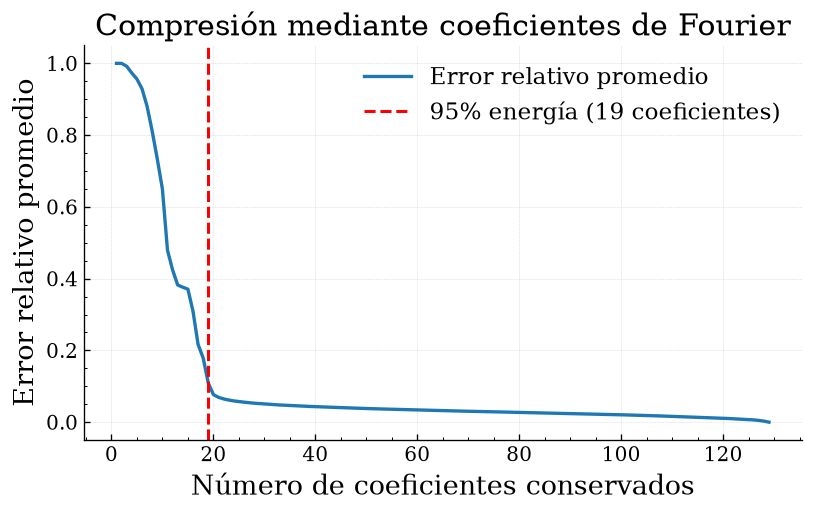

In [27]:
# Crea una figura para representar el error relativo promedio
# en función del número de coeficientes conservados.
plt.figure(figsize=(7, 4.5))

# Grafica la evolución del error relativo promedio.
plt.plot(Ks, errores, lw=2, label="Error relativo promedio")

# Agrega una línea vertical en el número mínimo de coeficientes
# que conserva al menos el 95 % de la energía promedio.
plt.axvline(
    k95,
    linestyle="--",
    color="red",
    lw=1.8,
    label=f"95% energía ({k95} coeficientes)"
)

# Define las etiquetas de los ejes y el título de la figura.
plt.xlabel("Número de coeficientes conservados")
plt.ylabel("Error relativo promedio")
plt.title("Compresión mediante coeficientes de Fourier")

# Activa la cuadrícula y muestra la leyenda de la gráfica.
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
# Ajusta automáticamente los márgenes de la figura.
plt.tight_layout()
plt.show()

**Figura 5.** Error relativo promedio de reconstrucción al conservar un número creciente de coeficientes de Fourier. La línea vertical indica el número mínimo de coeficientes necesario para preservar el **95 % de la energía** del conjunto de señales.

El error relativo disminuye a medida que aumenta el número de coeficientes conservados. El umbral del **95 % de la energía** se alcanza con **19 coeficientes**, lo que indica que las señales del conjunto de datos pueden representarse de forma comprimida sin perder gran parte de su información.

# 5. Conclusiones

Se implementó una red neuronal en JAX para reconstruir señales temporales, comparando dos estrategias de inicialización para la primera capa: una basada en la matriz de Fourier y otra aleatoria.

La verificación inicial mostró que la capa Fourier reproduce los coeficientes trigonométricos esperados al compararse con `np.fft.rfft`. Esto confirma que la primera capa parte de una representación espectral coherente con la estructura de las señales.

Ambas inicializaciones lograron reconstrucciones de alta precisión, con pérdidas finales entre $10^{-12}$ y $10^{-11}$ y errores relativos muy pequeños. Sin embargo, la inicialización Fourier alcanzó el umbral $\varepsilon < 0.1$ en **221 iteraciones**, mientras que la inicialización aleatoria necesitó **270 iteraciones**. Esto evidencia una convergencia más rápida al comenzar desde una base espectral.



Esta ventaja también se observó en el régimen $0$ (sin dispersión), donde la inicialización Fourier alcanzó el mismo umbral en **166 iteraciones**, frente a **209 iteraciones** para la inicialización aleatoria.

El análisis de compresión mostró que basta conservar **19 coeficientes de Fourier** para preservar aproximadamente el **95 % de la energía** del conjunto de datos. Esto indica que las señales admiten una representación espectral compacta.

En conjunto, los resultados permiten responder afirmativamente la pregunta central del trabajo: iniciar la red con una base de Fourier ayuda durante las primeras etapas del entrenamiento, ya que acelera la convergencia sin afectar la alta precisión final alcanzada por ambas estrategias.